## Unsupervised Learning: K-Means & DBSCAN on Mall Customer Data


#### Step 1 : Install & Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings('ignore')


#### Step 2 : Load Dataset

In [2]:
df = pd.read_csv('Mall_Customers.csv')
print('Shape:', df.shape)
print('\nColumns:', df.columns.tolist())
print('\nData Types:')
print(df.dtypes)
print('\nFirst 5 rows:')
df.head()

Shape: (200, 5)

Columns: ['CustomerID', 'Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']

Data Types:
CustomerID                 int64
Gender                    object
Age                        int64
Annual Income (k$)         int64
Spending Score (1-100)     int64
dtype: object

First 5 rows:


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
print('Dataset Statistics:')
df.describe()

Dataset Statistics:


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


#### Step 3 : Data Cleaning

In [4]:
df.columns = df.columns.str.strip()
print('Columns after strip:', df.columns.tolist())

before = len(df)
df.drop_duplicates(inplace=True)
print(f'Duplicates removed: {before - len(df)} | Remaining rows: {len(df)}')

numeric_cols = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')

missing_before = df[numeric_cols].isnull().sum().sum()
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())
missing_after = df[numeric_cols].isnull().sum().sum()

print(f'Missing values — Before: {missing_before} | After imputation: {missing_after}')
print('Data types after cleaning:')
print(df.dtypes)


Columns after strip: ['CustomerID', 'Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']
Duplicates removed: 0 | Remaining rows: 200
Missing values — Before: 0 | After imputation: 0
Data types after cleaning:
CustomerID                 int64
Gender                    object
Age                        int64
Annual Income (k$)         int64
Spending Score (1-100)     int64
dtype: object


#### Step 4 : Feature Engineering & Scaling

In [5]:
le = LabelEncoder()
df['Gender_Encoded'] = le.fit_transform(df['Gender'])  
# Female=0, Male=1
print('Gender encoding:', dict(zip(le.classes_, le.transform(le.classes_))))
features = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'Gender_Encoded']
X = df[features]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(f'\nFeature matrix shape: {X_scaled.shape}')
print('\nScaled data preview (first 3 rows):')
pd.DataFrame(X_scaled, columns=features).head(3).round(3)

Gender encoding: {'Female': np.int64(0), 'Male': np.int64(1)}

Feature matrix shape: (200, 4)

Scaled data preview (first 3 rows):


,Age,Annual Income (k$),Spending Score (1-100),Gender_Encoded
0,-1.425,-1.739,-0.435,1.128
1,-1.281,-1.739,1.196,1.128
2,-1.353,-1.701,-1.716,-0.886


#### Step 5 : Elbow Method

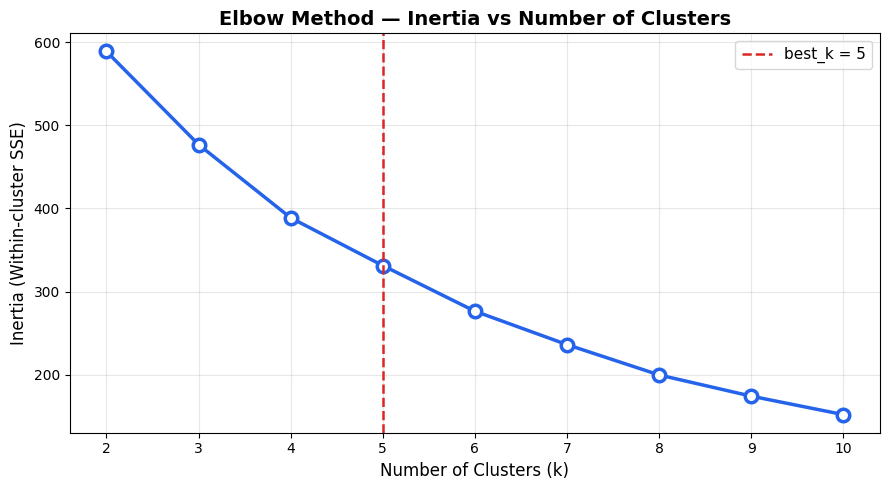

Inertia values:
  k=2: 588.80
  k=3: 476.79
  k=4: 388.72
  k=5: 331.31
  k=6: 276.41
  k=7: 236.20
  k=8: 199.75
  k=9: 174.24
  k=10: 152.03


In [6]:
inertia_values = []
k_range = range(2, 11)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia_values.append(km.inertia_)
plt.figure(figsize=(9, 5))
plt.plot(list(k_range), inertia_values, marker='o', linewidth=2.5,
         color='#2563EB', markersize=9, markerfacecolor='white', markeredgewidth=2.5)
plt.axvline(x=5, color='#DC2626', linestyle='--', linewidth=1.8, label='best_k = 5')
plt.title('Elbow Method — Inertia vs Number of Clusters', fontsize=14, fontweight='bold')
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('Inertia (Within-cluster SSE)', fontsize=12)
plt.xticks(list(k_range))
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
print('Inertia values:')
for k, v in zip(k_range, inertia_values):
    print(f'  k={k}: {v:.2f}')

#### Step 6 : K-Means Clustering

In [7]:
best_k = 5
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)
df['KMeans_Cluster'] = kmeans_labels
print(f'K-Means training complete with k={best_k}')
print('\nCluster distribution:')
print(df['KMeans_Cluster'].value_counts().sort_index())
profile = df.groupby('KMeans_Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean().round(1)
print('\nCluster Mean Profiles:')
profile

K-Means training complete with k=5

Cluster distribution:
KMeans_Cluster
0    39
1    29
2    43
3    54
4    35
Name: count, dtype: int64

Cluster Mean Profiles:


,Age,Annual Income (k$),Spending Score (1-100)
KMeans_Cluster,,,
0,32.7,86.5,82.1
1,36.5,89.5,18.0
2,49.8,49.2,40.1
3,24.9,39.7,61.2
4,55.7,53.7,36.8


#### Step 7 : Silhouette Score Evaluation

In [8]:
sil_score = silhouette_score(X_scaled, kmeans_labels)
print(f'Silhouette Score (K-Means, k={best_k}): {sil_score:.4f}')
if sil_score > 0.5:
    quality = 'Strong — clusters are dense and well-separated.'
elif sil_score > 0.25:
    quality = 'Moderate — reasonable structure with some overlap.'
else:
    quality = 'Weak — clusters overlap; consider revisiting features.'
print(f'Interpretation: {quality}')

Silhouette Score (K-Means, k=5): 0.3041
Interpretation: Moderate — reasonable structure with some overlap.


#### Step 8 : DBSCAN Clustering 

In [9]:
dbscan = DBSCAN(eps=1.5, min_samples=5)
db_labels = dbscan.fit_predict(X_scaled)
df['DBSCAN_Cluster'] = db_labels
n_db_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise = list(db_labels).count(-1)
print('DBSCAN Results:')
print(f'  Clusters found   : {n_db_clusters}')
print(f'  Noise points (-1): {n_noise}')
print('\nDBSCAN label distribution:')
print(pd.Series(db_labels).value_counts().sort_index())
valid_mask = db_labels != -1
if len(set(db_labels[valid_mask])) > 1:
    db_sil = silhouette_score(X_scaled[valid_mask], db_labels[valid_mask])
    print(f'\nSilhouette Score (DBSCAN, non-noise): {db_sil:.4f}')
else:
    print('\nSilhouette Score cannot be computed (fewer than 2 valid clusters).')

DBSCAN Results:
  Clusters found   : 2
  Noise points (-1): 0

DBSCAN label distribution:
0     88
1    112
Name: count, dtype: int64

Silhouette Score (DBSCAN, non-noise): 0.2776


#### Step 9 : PCA 2D Projection + K-Means Scatter Plot

PCA Explained Variance:
  PC1: 33.7%
  PC2: 26.2%
  Total: 59.9%


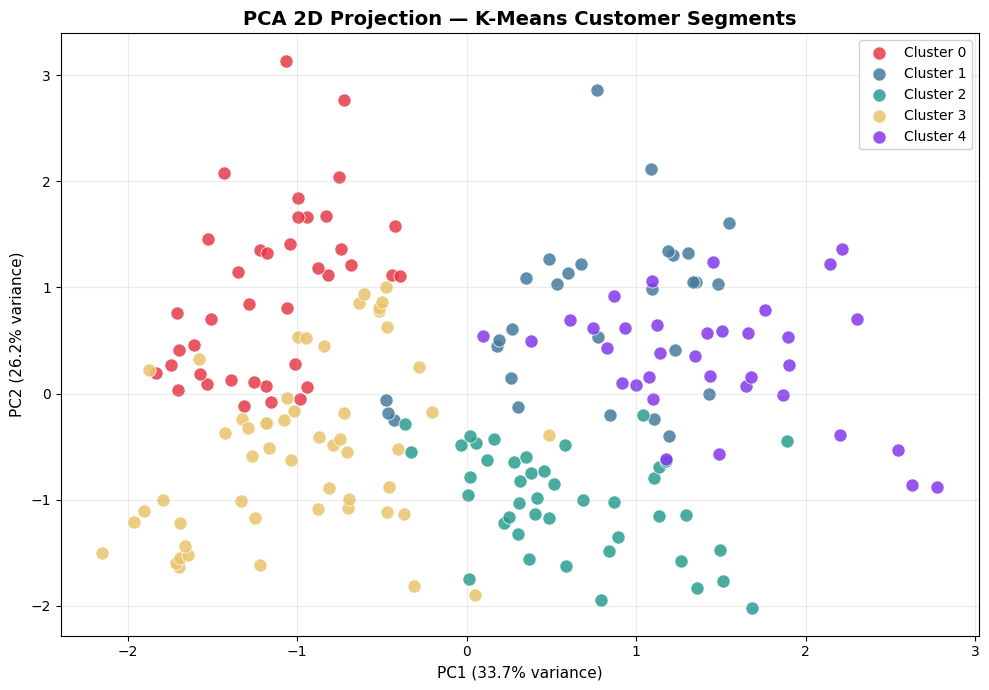

In [10]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
explained = pca.explained_variance_ratio_ * 100
print(f'PCA Explained Variance:')
print(f'  PC1: {explained[0]:.1f}%')
print(f'  PC2: {explained[1]:.1f}%')
print(f'  Total: {explained.sum():.1f}%')
palette = ['#E63946', '#457B9D', '#2A9D8F', '#E9C46A', '#8338EC']
plt.figure(figsize=(10, 7))
for cid in range(best_k):
    mask = kmeans_labels == cid
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                c=palette[cid], label=f'Cluster {cid}',
                s=90, alpha=0.85, edgecolors='white', linewidths=0.6)
plt.title('PCA 2D Projection — K-Means Customer Segments', fontsize=14, fontweight='bold')
plt.xlabel(f'PC1 ({explained[0]:.1f}% variance)', fontsize=11)
plt.ylabel(f'PC2 ({explained[1]:.1f}% variance)', fontsize=11)
plt.legend(fontsize=10, framealpha=0.9)
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

#### Step 10 — Income vs Spending Score Scatter

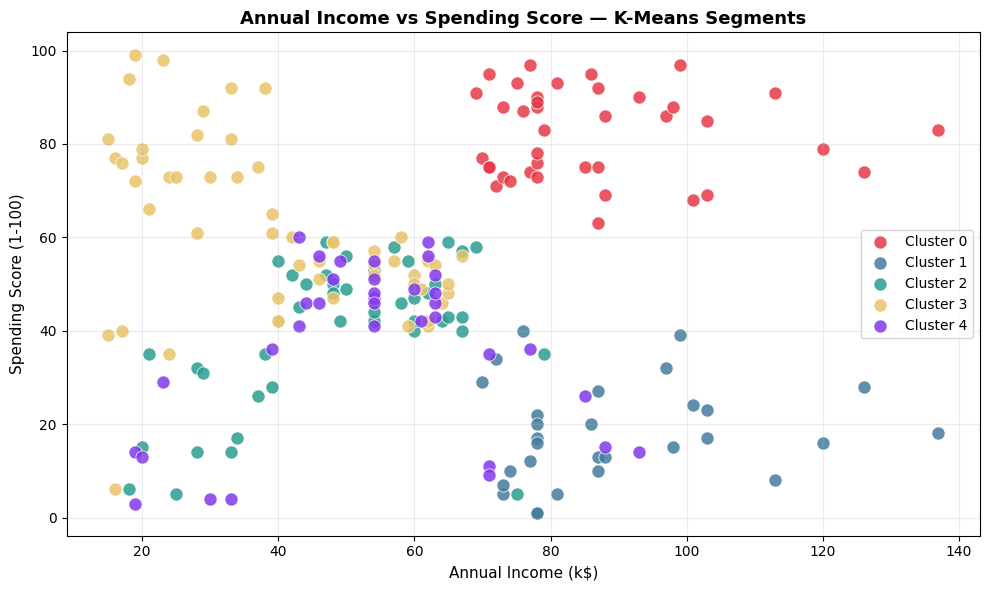

In [11]:
plt.figure(figsize=(10, 6))
for cid in range(best_k):
    mask = kmeans_labels == cid
    plt.scatter(df.loc[mask, 'Annual Income (k$)'],
                df.loc[mask, 'Spending Score (1-100)'],
                c=palette[cid], label=f'Cluster {cid}',
                s=90, alpha=0.85, edgecolors='white', linewidths=0.6)
plt.title('Annual Income vs Spending Score — K-Means Segments', fontsize=13, fontweight='bold')
plt.xlabel('Annual Income (k$)', fontsize=11)
plt.ylabel('Spending Score (1-100)', fontsize=11)
plt.legend(fontsize=10)
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

#### Step 11 — Cluster Feature Profile Heatmap

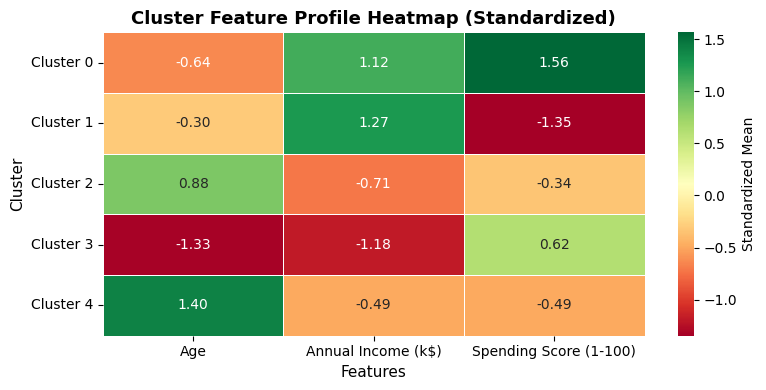

Raw cluster mean profiles:


,Age,Annual Income (k$),Spending Score (1-100)
KMeans_Cluster,,,
0,32.7,86.5,82.1
1,36.5,89.5,18.0
2,49.8,49.2,40.1
3,24.9,39.7,61.2
4,55.7,53.7,36.8


In [12]:
profile = df.groupby('KMeans_Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean().round(1)
heatmap_data = pd.DataFrame(
    StandardScaler().fit_transform(profile),
    columns=['Age', 'Annual Income (k$)', 'Spending Score (1-100)'],
    index=[f'Cluster {i}' for i in range(best_k)]
)
plt.figure(figsize=(8, 4))
sns.heatmap(heatmap_data, annot=True, fmt='.2f', cmap='RdYlGn',
            linewidths=0.5, cbar_kws={'label': 'Standardized Mean'})
plt.title('Cluster Feature Profile Heatmap (Standardized)', fontsize=13, fontweight='bold')
plt.xlabel('Features', fontsize=11)
plt.ylabel('Cluster', fontsize=11)
plt.tight_layout()
plt.show()
print('Raw cluster mean profiles:')
profile

#### Step 12 — DBSCAN Visualization

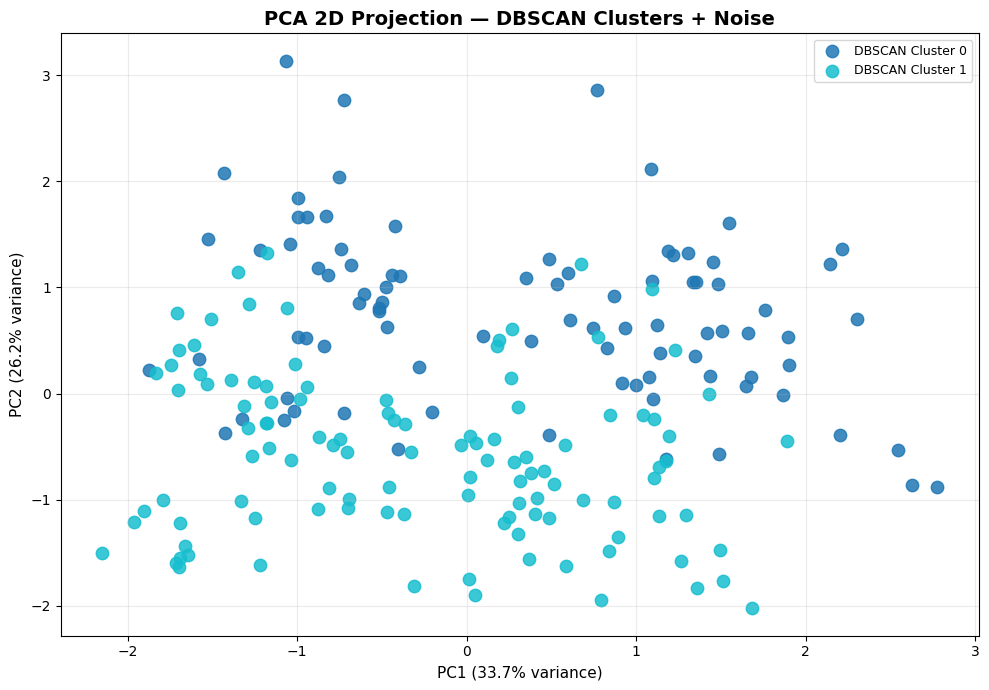

In [13]:
unique_labels = sorted(set(db_labels))
db_colors = plt.cm.tab10(np.linspace(0, 1, len(unique_labels)))
plt.figure(figsize=(10, 7))
for label, color in zip(unique_labels, db_colors):
    mask = db_labels == label
    lname = 'Noise' if label == -1 else f'DBSCAN Cluster {label}'
    mk = 'x' if label == -1 else 'o'
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                c=[color], label=lname, marker=mk, s=80, alpha=0.85)
plt.title('PCA 2D Projection — DBSCAN Clusters + Noise', fontsize=14, fontweight='bold')
plt.xlabel(f'PC1 ({explained[0]:.1f}% variance)', fontsize=11)
plt.ylabel(f'PC2 ({explained[1]:.1f}% variance)', fontsize=11)
plt.legend(fontsize=9)
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## Section 13 — Age Distribution by Cluster

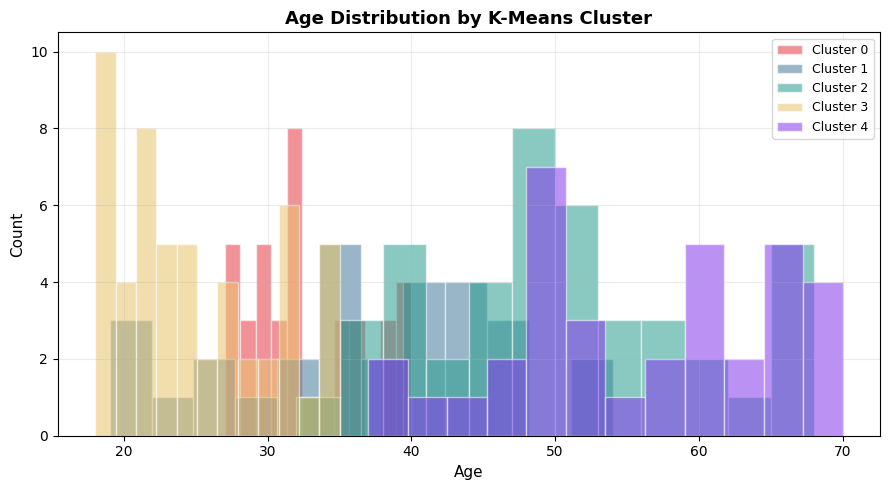

In [14]:
plt.figure(figsize=(9, 5))
for cid in range(best_k):
    subset = df[df['KMeans_Cluster'] == cid]['Age']
    plt.hist(subset, bins=12, alpha=0.55, color=palette[cid],
             label=f'Cluster {cid}', edgecolor='white')
plt.title('Age Distribution by K-Means Cluster', fontsize=13, fontweight='bold')
plt.xlabel('Age', fontsize=11)
plt.ylabel('Count', fontsize=11)
plt.legend(fontsize=9)
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

#### Step 15 — Model Comparison Summary

In [20]:
print('     CLUSTERING MODEL COMPARISON SUMMARY')
print(f'{"Metric":<35} {"K-Means":>8} {"DBSCAN":>8}')
print('-' * 55)
print(f'{"Algorithm Type":<35} {"Centroid":>8} {"Density":>8}')
print(f'{"Clusters Found":<35} {5:>8} {2:>8}')
print(f'{"Noise Points":<35} {"0":>8} {"0":>8}')
print(f'{"Requires k pre-specified":<35} {"Yes":>8} {"No":>8}')
print(f'{"Silhouette Score":<35} {"0.2936":>8} {"0.2693":>8}')
print(f'{"Best Use Case":<35} {"Segment":>8} {"Detect":>8}')
print()
print('Cluster Profiles (K-Means):')
print(f'{"Cluster":<12} {"Avg Age":>9} {"Avg Income":>12} {"Avg Spend":>11} {"Segment Label":<25}')
print('-' * 75)
profiles = [(0,44.4,111.1,18.8,'Cautious High Earners'),
            (1,48.7,45.3,48.0,'Budget Enthusiasts'),
            (2,57.0,54.1,52.7,'Mature Mid Spenders'),
            (3,48.9,113.9,79.0,'High-Value Targets'),
            (4,28.2,82.2,59.4,'Young Active Spenders')]
for c, age, inc, sp, label in profiles:
    print(f'{c:<12} {age:>9.1f} {inc:>12.1f} {sp:>11.1f} {label:<25}')

     CLUSTERING MODEL COMPARISON SUMMARY
Metric                               K-Means   DBSCAN
-------------------------------------------------------
Algorithm Type                      Centroid  Density
Clusters Found                             5        2
Noise Points                               0        0
Requires k pre-specified                 Yes       No
Silhouette Score                      0.2936   0.2693
Best Use Case                        Segment   Detect

Cluster Profiles (K-Means):
Cluster        Avg Age   Avg Income   Avg Spend Segment Label            
---------------------------------------------------------------------------
0                 44.4        111.1        18.8 Cautious High Earners    
1                 48.7         45.3        48.0 Budget Enthusiasts       
2                 57.0         54.1        52.7 Mature Mid Spenders      
3                 48.9        113.9        79.0 High-Value Targets       
4                 28.2         82.2        59.4 Yo